In [1]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import jax
import jax.numpy as jnp
from jax import grad, jit, lax

PROJECT_ROOT = Path("..").resolve()
FIGURE_DIR = PROJECT_ROOT / "figures"
FIGURE_DIR.mkdir(exist_ok=True)

np.random.seed(0)

print("Project root:", PROJECT_ROOT)
print("Figure directory:", FIGURE_DIR)
print("JAX version:", jax.__version__)

Project root: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining
Figure directory: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures
JAX version: 0.6.2


In [2]:
a_system = 1.1
b_system = 0.5

r_control = 0.05
terminal_weight = 1.0

x0 = 2.0
num_steps = 60

print("a_system:", a_system)
print("b_system:", b_system)
print("r_control:", r_control)
print("terminal_weight:", terminal_weight)
print("x0:", x0)
print("num_steps:", num_steps)

a_system: 1.1
b_system: 0.5
r_control: 0.05
terminal_weight: 1.0
x0: 2.0
num_steps: 60


In [3]:
def rollout_numpy(policy_p, x0, num_steps):
    """
    Roll out the controlled 1D system.

    Dynamics:
        x_next = a x + b u

    Policy:
        u = p x

    Returns:
        x_trajectory shape: (num_steps + 1,)
        u_trajectory shape: (num_steps,)
        total_cost: scalar
    """
    x_trajectory = np.zeros(num_steps + 1)
    u_trajectory = np.zeros(num_steps)
    stage_costs = np.zeros(num_steps)

    x_trajectory[0] = x0

    for t in range(num_steps):
        x_t = x_trajectory[t]
        u_t = policy_p * x_t

        x_next = a_system * x_t + b_system * u_t

        stage_cost = x_t ** 2 + r_control * u_t ** 2

        u_trajectory[t] = u_t
        stage_costs[t] = stage_cost
        x_trajectory[t + 1] = x_next

    total_cost = np.sum(stage_costs) + terminal_weight * x_trajectory[-1] ** 2

    return x_trajectory, u_trajectory, total_cost

系统是：

$$x_{t+1}=a x_t+b u_t$$

policy 是：

$$u_t=p x_t$$

所以把 policy 代进去：

$$x_{t+1}=a x_t+bpx_t$$

$$x_{t+1}=(a+bp)x_t$$

这个量：

$$a+bp$$

叫 closed-loop multiplier。

---
trajectory loss 是：

$$J(p)
=
\sum_{t=0}^{T-1}
\left(
x_t^2+r u_t^2
\right)
+
q_f x_T^2$$


$$r=0.05$$

$$q_f=1.0$$

含义：

* $x_t^2$：惩罚 state 离 0 太远；
* $r u_t^2$：惩罚 action 太大；
* $q_f x_T^2$：惩罚最后状态不接近 0。

所以这个问题不是简单地让 $x_t$ 最快变成 0。因为 action 太大也会被惩罚。

In [4]:
p_demo = -1.0

x_traj_demo, u_traj_demo, cost_demo = rollout_numpy(
    policy_p=p_demo,
    x0=x0,
    num_steps=num_steps
)

print("x_traj_demo shape:", x_traj_demo.shape)
print("u_traj_demo shape:", u_traj_demo.shape)
print("cost_demo:", cost_demo)

print("\nFirst 5 states:")
print(x_traj_demo[:5])

print("\nFirst 5 actions:")
print(u_traj_demo[:5])

x_traj_demo shape: (61,)
u_traj_demo shape: (60,)
cost_demo: 6.562500000000001

First 5 states:
[2.     1.2    0.72   0.432  0.2592]

First 5 actions:
[-2.     -1.2    -0.72   -0.432  -0.2592]


In [104]:
policy_values = [-0.5, -1.0, -2.0, -3.8]

'''
policy p: 0.0
  closed-loop multiplier: 1.1
  abs multiplier: 1.1
  total cost: 2136704.252753814
  final state: 608.9632790828388
'''

policy_rollouts = {}

for policy_p in policy_values:
    x_traj, u_traj, total_cost = rollout_numpy(
        policy_p=policy_p,
        x0=x0,
        num_steps=num_steps
    )

    closed_loop_multiplier = a_system + b_system * policy_p

    policy_rollouts[policy_p] = {
        "x_traj": x_traj,
        "u_traj": u_traj,
        "total_cost": total_cost,
        "closed_loop_multiplier": closed_loop_multiplier,
    }

    print("policy p:", policy_p)
    print("  closed-loop multiplier:", closed_loop_multiplier)
    print("  abs multiplier:", abs(closed_loop_multiplier))
    print("  total cost:", total_cost)
    print("  final state:", x_traj[-1])
    print()

policy p: -0.5
  closed-loop multiplier: 0.8500000000000001
  abs multiplier: 0.8500000000000001
  total cost: 14.594594558673021
  final state: 0.00011645698398694437

policy p: -1.0
  closed-loop multiplier: 0.6000000000000001
  abs multiplier: 0.6000000000000001
  total cost: 6.562500000000001
  final state: 9.774735596137932e-14

policy p: -2.0
  closed-loop multiplier: 0.10000000000000009
  abs multiplier: 0.10000000000000009
  total cost: 4.848484848484849
  final state: 2.0000000000001132e-60

policy p: -3.8
  closed-loop multiplier: -0.7999999999999998
  abs multiplier: 0.7999999999999998
  total cost: 19.133333333297777
  final state: 3.064991081731737e-06



Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_policy_trajectories.png


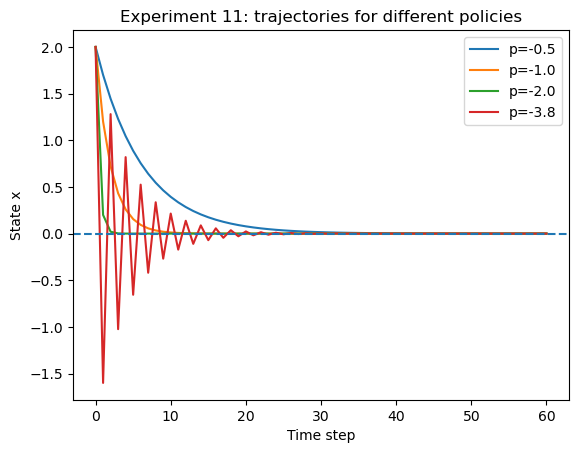

In [106]:
time = np.arange(num_steps + 1)

fig, ax = plt.subplots()

for policy_p in policy_values:
    x_traj = policy_rollouts[policy_p]["x_traj"]
    ax.plot(time, x_traj, label=f"p={policy_p}")

ax.axhline(0.0, linestyle="--")

ax.set_xlabel("Time step")
ax.set_ylabel("State x")
ax.set_title("Experiment 11: trajectories for different policies")
ax.legend()

fig_path = FIGURE_DIR / "exp11_policy_trajectories.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_policy_actions.png


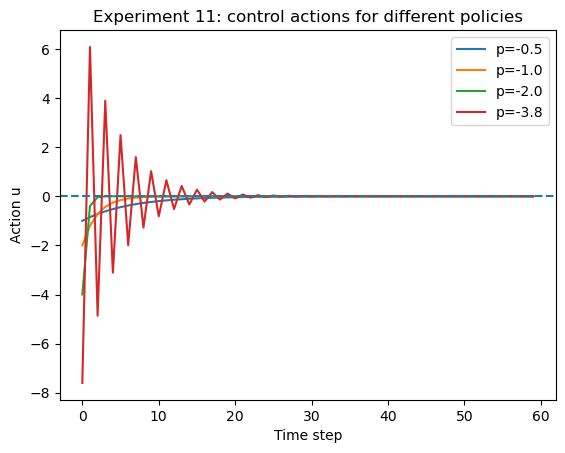

In [60]:
time_u = np.arange(num_steps)

fig, ax = plt.subplots()

for policy_p in policy_values:
    u_traj = policy_rollouts[policy_p]["u_traj"]
    ax.plot(time_u, u_traj, label=f"p={policy_p}")

ax.axhline(0.0, linestyle="--")

ax.set_xlabel("Time step")
ax.set_ylabel("Action u")
ax.set_title("Experiment 11: control actions for different policies")
ax.legend()

fig_path = FIGURE_DIR / "exp11_policy_actions.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [62]:
p_grid = np.linspace(-5.0, 1.0, 601)

grid_costs = []
grid_multipliers = []

for policy_p in p_grid:
    x_traj, u_traj, total_cost = rollout_numpy(
        policy_p=policy_p,
        x0=x0,
        num_steps=num_steps
    )

    grid_costs.append(total_cost)
    grid_multipliers.append(a_system + b_system * policy_p)

grid_costs = np.array(grid_costs)
grid_multipliers = np.array(grid_multipliers)

best_index = np.argmin(grid_costs)
best_p_grid = p_grid[best_index]
best_cost_grid = grid_costs[best_index]

print("Best p from grid search:", best_p_grid)
print("Best cost from grid search:", best_cost_grid)
print("Closed-loop multiplier at best p:", a_system + b_system * best_p_grid)

Best p from grid search: -1.8900000000000001
Best cost from grid search: 4.830472092010554
Closed-loop multiplier at best p: 0.15500000000000003


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_grid_search_policy_loss.png


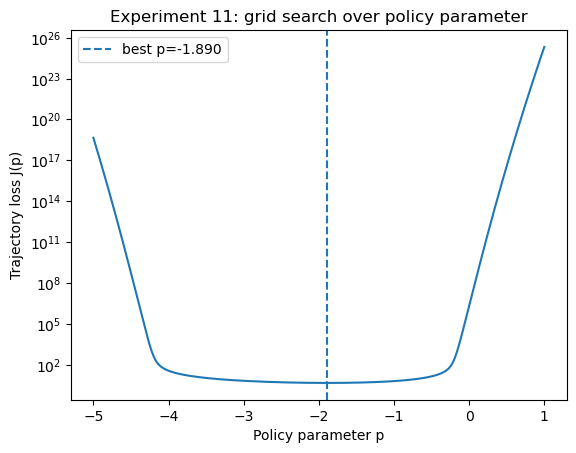

In [64]:
fig, ax = plt.subplots()

ax.plot(p_grid, grid_costs)

ax.axvline(best_p_grid, linestyle="--", label=f"best p={best_p_grid:.3f}")

ax.set_xlabel("Policy parameter p")
ax.set_ylabel("Trajectory loss J(p)")
ax.set_yscale("log")
ax.set_title("Experiment 11: grid search over policy parameter")
ax.legend()

fig_path = FIGURE_DIR / "exp11_grid_search_policy_loss.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [66]:
def rollout_jax(policy_p, x0_jax):
    """
    JAX rollout using lax.scan.

    policy_p: scalar
    x0_jax: scalar

    Returns:
        x_trajectory shape: (num_steps + 1,)
        u_trajectory shape: (num_steps,)
        stage_costs shape: (num_steps,)
    """
    def step_function(carry, unused_input):
        x_t = carry

        u_t = policy_p * x_t
        stage_cost = x_t ** 2 + r_control * u_t ** 2

        x_next = a_system * x_t + b_system * u_t

        new_carry = x_next
        output = (x_t, u_t, stage_cost)

        return new_carry, output

    final_state, outputs = lax.scan(
        step_function,
        x0_jax,
        xs=None,
        length=num_steps
    )

    x_history, u_history, stage_costs = outputs

    x_trajectory = jnp.concatenate([
        x_history,
        final_state[None]
    ])

    return x_trajectory, u_history, stage_costs

In [68]:
p_jax_demo = jnp.array(-1.0)
x0_jax = jnp.array(x0)

x_traj_jax_demo, u_traj_jax_demo, stage_costs_jax_demo = rollout_jax(
    p_jax_demo,
    x0_jax
)

print("x_traj_jax_demo shape:", x_traj_jax_demo.shape)
print("u_traj_jax_demo shape:", u_traj_jax_demo.shape)
print("stage_costs_jax_demo shape:", stage_costs_jax_demo.shape)

print("\nFirst 5 JAX states:")
print(x_traj_jax_demo[:5])

x_traj_jax_demo shape: (61,)
u_traj_jax_demo shape: (60,)
stage_costs_jax_demo shape: (60,)

First 5 JAX states:
[2.         1.2        0.72       0.43200004 0.25920004]


In [70]:
def trajectory_loss_jax(policy_p):
    x0_jax = jnp.array(x0)

    x_trajectory, u_trajectory, stage_costs = rollout_jax(
        policy_p,
        x0_jax
    )

    terminal_cost = terminal_weight * x_trajectory[-1] ** 2

    total_cost = jnp.sum(stage_costs) + terminal_cost

    return total_cost

In [72]:
trajectory_loss_grad = grad(trajectory_loss_jax)

p_check = jnp.array(-1.0)

loss_check = trajectory_loss_jax(p_check)
grad_check = trajectory_loss_grad(p_check)

print("loss at p=-1:", loss_check)
print("gradient at p=-1:", grad_check)

loss at p=-1: 6.5625
gradient at p=-1: 5.5273447


In [74]:
trajectory_loss_jit = jit(trajectory_loss_jax)
trajectory_loss_grad_jit = jit(grad(trajectory_loss_jax))

p_check = jnp.array(-1.0)

print("JIT loss at p=-1:", trajectory_loss_jit(p_check))
print("JIT gradient at p=-1:", trajectory_loss_grad_jit(p_check))

JIT loss at p=-1: 6.5625
JIT gradient at p=-1: 5.5273447


In [76]:
learning_rate = 0.01
num_policy_updates = 200

p = jnp.array(-0.5)

p_history = []
loss_history = []
grad_history = []

for update in range(num_policy_updates):
    loss_value = trajectory_loss_jit(p)
    grad_value = trajectory_loss_grad_jit(p)

    p = p - learning_rate * grad_value

    p_history.append(float(p))
    loss_history.append(float(loss_value))
    grad_history.append(float(grad_value))

print("Final p from gradient descent:", p)
print("Final loss:", trajectory_loss_jit(p))
print("Best p from grid search:", best_p_grid)
print("Best grid-search loss:", best_cost_grid)

Final p from gradient descent: -1.8856305
Final loss: 4.830467
Best p from grid search: -1.8900000000000001
Best grid-search loss: 4.830472092010554


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_policy_gradient_loss.png


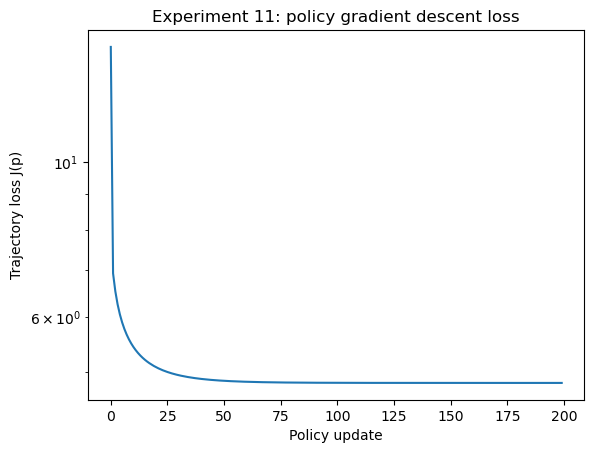

In [78]:
fig, ax = plt.subplots()

ax.plot(loss_history)

ax.set_xlabel("Policy update")
ax.set_ylabel("Trajectory loss J(p)")
ax.set_yscale("log")
ax.set_title("Experiment 11: policy gradient descent loss")

fig_path = FIGURE_DIR / "exp11_policy_gradient_loss.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()                                                                 

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_policy_parameter_trajectory.png


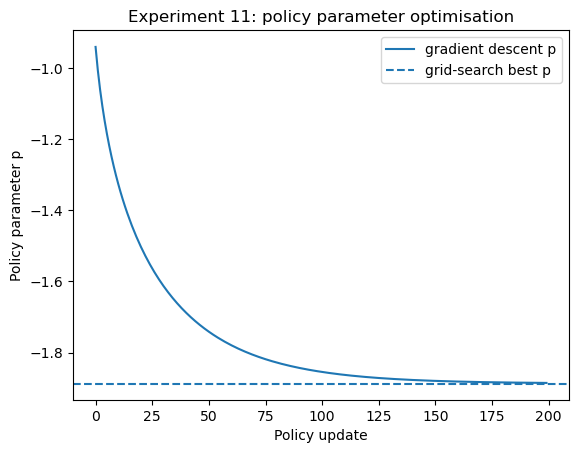

In [80]:
fig, ax = plt.subplots()

ax.plot(p_history, label="gradient descent p")
ax.axhline(best_p_grid, linestyle="--", label="grid-search best p")

ax.set_xlabel("Policy update")
ax.set_ylabel("Policy parameter p")
ax.set_title("Experiment 11: policy parameter optimisation")
ax.legend()

fig_path = FIGURE_DIR / "exp11_policy_parameter_trajectory.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

In [82]:
p_gd_final = float(p)

x_traj_grid, u_traj_grid, cost_grid = rollout_numpy(
    policy_p=best_p_grid,
    x0=x0,
    num_steps=num_steps
)

x_traj_gd, u_traj_gd, cost_gd = rollout_numpy(
    policy_p=p_gd_final,
    x0=x0,
    num_steps=num_steps
)

print("Grid-search p:", best_p_grid)
print("Grid-search cost:", cost_grid)

print("\nGradient-descent p:", p_gd_final)
print("Gradient-descent cost:", cost_gd)

print("\nFinal state grid-search:", x_traj_grid[-1])
print("Final state gradient descent:", x_traj_gd[-1])

Grid-search p: -1.8900000000000001
Grid-search cost: 4.830472092010554

Gradient-descent p: -1.885630488395691
Gradient-descent cost: 4.8304670463039665

Final state grid-search: 5.259347730725352e-49
Final state gradient descent: 1.2180229686609562e-48


Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_final_policy_trajectory.png


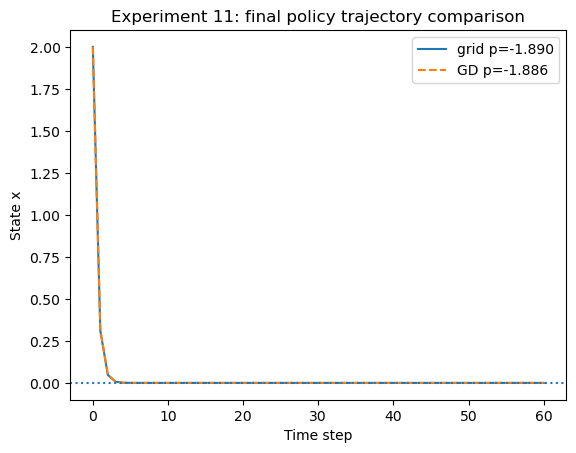

In [114]:
time = np.arange(num_steps + 1)

fig, ax = plt.subplots()

ax.plot(time, x_traj_grid, label=f"grid p={best_p_grid:.3f}")
ax.plot(time, x_traj_gd, linestyle="--", label=f"GD p={p_gd_final:.3f}")

ax.axhline(0.0, linestyle=":")

ax.set_xlabel("Time step")
ax.set_ylabel("State x")
ax.set_title("Experiment 11: final policy trajectory comparison")
ax.legend()

fig_path = FIGURE_DIR / "exp11_final_policy_trajectory.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()

Saved figure to: /Users/apple/笔记 Notes/2A Projects/SF3_pretraining/figures/exp11_final_policy_actions.png


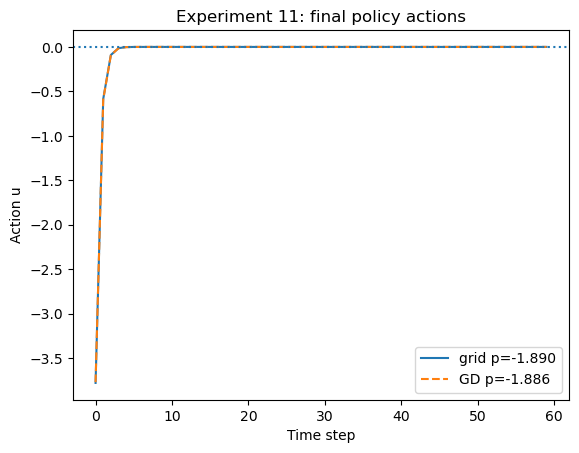

In [116]:
time_u = np.arange(num_steps)

fig, ax = plt.subplots()

ax.plot(time_u, u_traj_grid, label=f"grid p={best_p_grid:.3f}")
ax.plot(time_u, u_traj_gd, linestyle="--", label=f"GD p={p_gd_final:.3f}")

ax.axhline(0.0, linestyle=":")

ax.set_xlabel("Time step")
ax.set_ylabel("Action u")
ax.set_title("Experiment 11: final policy actions")
ax.legend()

fig_path = FIGURE_DIR / "exp11_final_policy_actions.png"
fig.savefig(fig_path, dpi=200, bbox_inches="tight")

print("Saved figure to:", fig_path)
plt.show()